In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from src import config
from src.dataset import BioHubDataset
from src.detector import CellDetector


In [ ]:
DATASET = BioHubDataset(config.DATASET_PATH)

DATASET.info()


In [6]:
sample = DATASET.train_samples[0]

print(sample)

volume = DATASET.load_volume(sample)

print(volume.shape)

44b6_0113de3b
(100, 64, 256, 256)


In [7]:
detector = CellDetector()

print(detector)

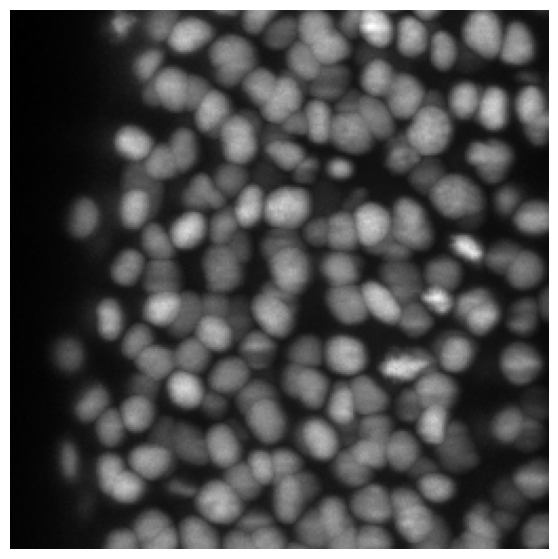

In [8]:
frame = np.asarray(volume[0])

mip = frame.max(axis=0)

plt.figure(figsize=(7,7))

plt.imshow(mip, cmap="gray")

plt.axis("off")

plt.show()

In [9]:
cells = detector.detect(mip)

print(f"Detected {len(cells)} cells")

cells[:10]

Detected 58 cells


array([[179,  82],
       [113, 217],
       [104,  84],
       [170, 185],
       [101, 171],
       [136, 202],
       [141,  72],
       [ 46, 229],
       [ 92, 130],
       [137, 175]])

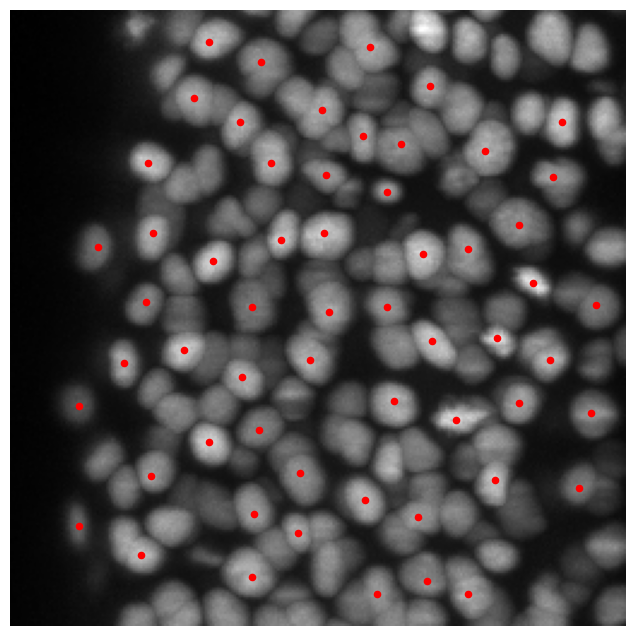

In [10]:
plt.figure(figsize=(8,8))

plt.imshow(mip, cmap="gray")

plt.scatter(
    cells[:,1],
    cells[:,0],
    s=20,
    c="red"
)

plt.axis("off")

plt.show()

In [11]:
all_detections = detector.detect_volume(volume)

In [12]:
counts = [len(c) for c in all_detections]

for i, n in enumerate(counts):
    print(f"Frame {i:3d}: {n:3d} cells")

Frame   0:  58 cells
Frame   1:  56 cells
Frame   2:  57 cells
Frame   3:  54 cells
Frame   4:  49 cells
Frame   5:  53 cells
Frame   6:  52 cells
Frame   7:  53 cells
Frame   8:  49 cells
Frame   9:  49 cells
Frame  10:  50 cells
Frame  11:  52 cells
Frame  12:  52 cells
Frame  13:  52 cells
Frame  14:  48 cells
Frame  15:  52 cells
Frame  16:  49 cells
Frame  17:  54 cells
Frame  18:  49 cells
Frame  19:  44 cells
Frame  20:  46 cells
Frame  21:  51 cells
Frame  22:  49 cells
Frame  23:  49 cells
Frame  24:  52 cells
Frame  25:  52 cells
Frame  26:  51 cells
Frame  27:  59 cells
Frame  28:  56 cells
Frame  29:  55 cells
Frame  30:  57 cells
Frame  31:  58 cells
Frame  32:  51 cells
Frame  33:  55 cells
Frame  34:  58 cells
Frame  35:  50 cells
Frame  36:  51 cells
Frame  37:  56 cells
Frame  38:  54 cells
Frame  39:  57 cells
Frame  40:  54 cells
Frame  41:  55 cells
Frame  42:  56 cells
Frame  43:  60 cells
Frame  44:  63 cells
Frame  45:  65 cells
Frame  46:  61 cells
Frame  47:  5

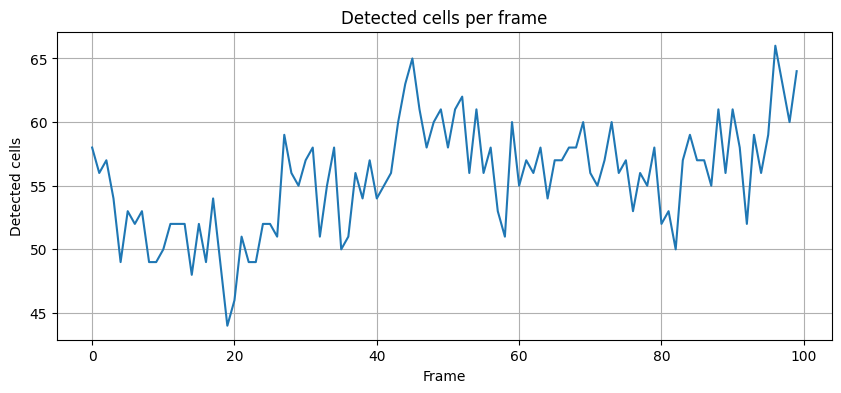

In [13]:
plt.figure(figsize=(10,4))

plt.plot(counts)

plt.xlabel("Frame")

plt.ylabel("Detected cells")

plt.title("Detected cells per frame")

plt.grid(True)

plt.show()